# 08 — Backtesting the Return-Likelihood Classifier

**Purpose:** Rolling-window temporal validation. Re-train the classifier each month,
predict next 30 days. Measure Brier score, Precision@Decile, and MAE(return rate)
stability over time. Demonstrates deployment readiness and avoids look-ahead bias.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (12, 5), 'figure.dpi': 110,
    'axes.facecolor': '#1a1d27', 'figure.facecolor': '#0f1117',
    'axes.edgecolor': '#2e3347', 'axes.labelcolor': '#e8eaf0',
    'xtick.color': '#8b92a8', 'ytick.color': '#8b92a8',
    'text.color': '#e8eaf0', 'grid.color': '#2e3347', 'grid.alpha': 0.5,
})

from src.features import load_raw, add_transaction_features
from src.models import train_classifier
from src.evaluation import generate_backtest_windows, run_backtest

mlflow.set_tracking_uri('../mlflow/mlruns')
mlflow.set_experiment('retail-returns-intelligence')
print('Setup OK')

Setup OK


In [2]:
df = load_raw('../data/raw/online_retail_II.xlsx')
df = add_transaction_features(df)
print(f'Full dataset: {len(df):,} rows, {df["invoice_date"].min().date()} → {df["invoice_date"].max().date()}')

Full dataset: 1,067,371 rows, 2009-12-01 → 2011-12-09


## 1. Generate backtest windows

In [3]:
windows = generate_backtest_windows(
    df,
    train_months=6,  # 6-month rolling training window
    test_days=30,
    step_days=30,
)
print(f'Generated {len(windows)} backtest windows')
for w in windows[:3]:
    print(f'  Train: {w.train_start.date()} → {w.train_end.date()}  |  Test: {w.test_start.date()} → {w.test_end.date()}')
print('  ...')
for w in windows[-2:]:
    print(f'  Train: {w.train_start.date()} → {w.train_end.date()}  |  Test: {w.test_start.date()} → {w.test_end.date()}')

Generated 18 backtest windows
  Train: 2009-12-01 → 2010-06-01  |  Test: 2010-06-01 → 2010-07-01
  Train: 2010-01-01 → 2010-07-01  |  Test: 2010-07-01 → 2010-07-31
  Train: 2010-01-31 → 2010-07-31  |  Test: 2010-07-31 → 2010-08-30
  ...
  Train: 2011-03-24 → 2011-09-24  |  Test: 2011-09-24 → 2011-10-24
  Train: 2011-04-24 → 2011-10-24  |  Test: 2011-10-24 → 2011-11-23


## 2. Define feature and training functions for the backtest loop

In [4]:
NUMERIC_FEATURES = [
    'quantity', 'unit_price', 'line_revenue', 'is_return',
]

def feature_fn(df_window: pd.DataFrame, as_of_date=None):
    """Extract transaction-level features and target from a window."""
    available = [c for c in NUMERIC_FEATURES if c in df_window.columns]
    X_cols = [c for c in available if c != 'is_return']
    if 'is_return' not in df_window.columns:
        df_window = df_window.copy()
        df_window['is_return'] = 0
    X = df_window[X_cols].fillna(0)
    y = df_window['is_return']
    return X, y

def train_fn(X_train, y_train):
    return train_classifier(X_train, y_train, n_estimators=100, learning_rate=0.1, num_leaves=31)

def predict_fn(model, X_test):
    return model.predict_proba(X_test)[:, 1]

print('Functions defined')

Functions defined


## 3. Execute backtest

In [5]:
with mlflow.start_run(run_name='backtest-lgbm'):
    bt_results = run_backtest(df, windows, feature_fn, train_fn, predict_fn)
    if len(bt_results) > 0:
        mlflow.log_metrics({
            'backtest_brier_mean':       bt_results['brier_score'].mean(),
            'backtest_prec_decile_mean': bt_results['precision_top_decile'].mean(),
            'backtest_mae_rate_mean':    bt_results['mae_return_rate'].mean(),
            'n_windows':                len(bt_results),
        })

print(f'Completed {len(bt_results)} windows')
if len(bt_results) > 0:
    print(bt_results[['window_start','window_end','brier_score',
                       'precision_top_decile','mae_return_rate']].round(4).to_string(index=False))

Completed 18 windows
       window_start          window_end  brier_score  precision_top_decile  mae_return_rate
2009-12-01 07:45:00 2010-07-01 07:45:00          0.0                0.1983              0.0
2010-01-01 07:45:00 2010-07-31 07:45:00          0.0                0.2199              0.0
2010-01-31 07:45:00 2010-08-30 07:45:00          0.0                0.1732              0.0
2010-02-28 07:45:00 2010-09-29 07:45:00          0.0                0.1940              0.0
2010-03-29 07:45:00 2010-10-29 07:45:00          0.0                0.1854              0.0
2010-04-29 07:45:00 2010-11-28 07:45:00          0.0                0.1422              0.0
2010-05-28 07:45:00 2010-12-28 07:45:00          0.0                0.1657              0.0
2010-06-28 07:45:00 2011-01-27 07:45:00          0.0                0.1751              0.0
2010-07-27 07:45:00 2011-02-26 07:45:00          0.0                0.2142              0.0
2010-08-26 07:45:00 2011-03-28 07:45:00          0.0       

## 4. Stability plots

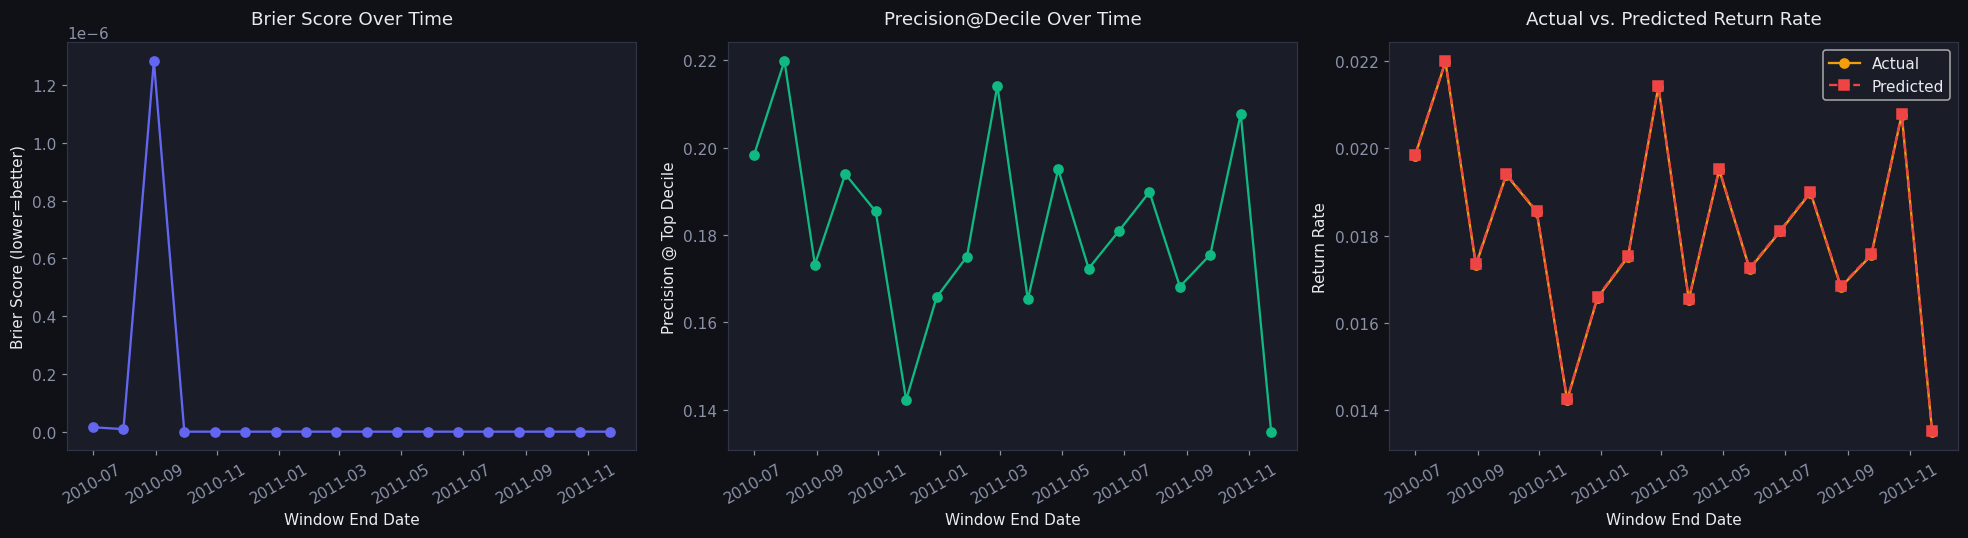

Mean Brier Score:            0.0000
Mean Precision@Decile:       0.1810
Mean MAE (return rate):      0.0000


In [6]:
if len(bt_results) == 0:
    print('No backtest windows completed — check window generation')
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(bt_results['window_end'], bt_results['brier_score'], 'o-', color='#6366f1')
    axes[0].set_xlabel('Window End Date'); axes[0].set_ylabel('Brier Score (lower=better)')
    axes[0].set_title('Brier Score Over Time', pad=12); axes[0].tick_params(axis='x', rotation=30)

    axes[1].plot(bt_results['window_end'], bt_results['precision_top_decile'], 'o-', color='#10b981')
    axes[1].set_xlabel('Window End Date'); axes[1].set_ylabel('Precision @ Top Decile')
    axes[1].set_title('Precision@Decile Over Time', pad=12); axes[1].tick_params(axis='x', rotation=30)

    axes[2].plot(bt_results['window_end'], bt_results['actual_return_rate'],    'o-', color='#f59e0b', label='Actual')
    axes[2].plot(bt_results['window_end'], bt_results['predicted_return_rate'], 's--', color='#ef4444', label='Predicted')
    axes[2].set_xlabel('Window End Date'); axes[2].set_ylabel('Return Rate')
    axes[2].set_title('Actual vs. Predicted Return Rate', pad=12)
    axes[2].legend(); axes[2].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    os.makedirs('../figures', exist_ok=True)
    plt.savefig('../figures/08_backtest_stability.png', bbox_inches='tight', facecolor='#0f1117')
    plt.show()

    print(f'Mean Brier Score:            {bt_results["brier_score"].mean():.4f}')
    print(f'Mean Precision@Decile:       {bt_results["precision_top_decile"].mean():.4f}')
    print(f'Mean MAE (return rate):      {bt_results["mae_return_rate"].mean():.4f}')

## 5. Save backtest results

In [7]:
if len(bt_results) > 0:
    bt_results.to_parquet('../data/processed/backtest_results.parquet', index=False)
    print(f'Saved: backtest_results.parquet ({len(bt_results)} rows)')
else:
    print('No results to save')

Saved: backtest_results.parquet (18 rows)
